# 14 — Diversity Metric Instrumentation

**Maps to:** `report/Chapters/Task2.tex` §`T2:RepairEffect` (and feeds Task 3 critique).  
**Ticket:** TICKET-14.

Pairwise Hamming + edge-overlap on the population each generation. Verify metric values make sense on a hand-crafted population before plugging into the loop.


## Metric Definitions

Two complementary diversity metrics are implemented:

- `pairwise_hamming(population)`: average pairwise Hamming distance, normalised by chromosome length. This measures positional diversity and is the metric expected by downstream plotting notebooks under the column name `diversity`.
- `edge_overlap(population)`: average fraction of shared undirected tour edges across all chromosome pairs. This is converted to edge diversity as `1 - edge_overlap`, so higher values mean less shared tour structure.

Hamming distance is cheap and useful for general population monitoring. Edge overlap is more TSP-specific because two tours can be rotations or reversals of the same cycle while still looking different position by position.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _as_population(population):
    pop = np.asarray(population)
    if pop.ndim != 2:
        raise ValueError("population must be a 2D array-like object")
    if pop.shape[1] == 0:
        raise ValueError("chromosomes must contain at least one city")
    return pop


def pairwise_hamming(population):
    """Return mean pairwise Hamming distance, normalised to [0, 1]."""
    pop = _as_population(population)
    n_individuals, n_genes = pop.shape

    if n_individuals < 2:
        return 0.0

    total = 0.0
    n_pairs = 0
    for i in range(n_individuals - 1):
        total += np.count_nonzero(pop[i] != pop[i + 1:], axis=1).sum()
        n_pairs += n_individuals - i - 1

    return float(total / (n_pairs * n_genes))


def tour_edges(tour):
    """Return the undirected edge set of a cyclic TSP tour."""
    tour = np.asarray(tour)
    return frozenset(
        tuple(sorted((int(tour[i]), int(tour[(i + 1) % len(tour)]))))
        for i in range(len(tour))
    )


def edge_overlap(population):
    """Return mean pairwise fraction of shared undirected tour edges."""
    pop = _as_population(population)
    n_individuals, n_genes = pop.shape

    if n_individuals < 2:
        return 1.0

    edge_sets = [tour_edges(tour) for tour in pop]
    total_overlap = 0.0
    n_pairs = 0

    for i in range(n_individuals - 1):
        for j in range(i + 1, n_individuals):
            total_overlap += len(edge_sets[i] & edge_sets[j]) / n_genes
            n_pairs += 1

    return float(total_overlap / n_pairs)


def edge_difference(population):
    """Return mean pairwise edge-difference distance, normalised to [0, 1]."""
    return float(1.0 - edge_overlap(population))


def diversity_record(generation, population):
    """Create one per-generation diversity log row."""
    pop = _as_population(population)
    overlap = edge_overlap(pop)
    return {
        "generation": int(generation),
        "pop_size": int(pop.shape[0]),
        "n_cities": int(pop.shape[1]),
        "diversity": pairwise_hamming(pop),
        "edge_overlap": overlap,
        "edge_diversity": 1.0 - overlap,
    }


## Hand-Crafted Validation

The first validation population contains three identical tours, so Hamming diversity is zero and edge overlap is one.

The second population is small enough to verify by hand:

- `a = [0, 1, 2, 3]`
- `b = [0, 2, 1, 3]`
- `c = [3, 2, 1, 0]`

For Hamming distance, the pairwise normalised distances are `0.50`, `1.00`, and `0.50`, so the average is `2/3`.

For edge overlap, tour `c` is the reverse of tour `a`, so they share all edges. Tours `a` and `b` share half their edges, and tours `b` and `c` also share half their edges. The mean edge overlap is therefore also `2/3`, giving edge diversity `1/3`.


In [2]:
identical_pop = np.array([
    [0, 1, 2, 3],
    [0, 1, 2, 3],
    [0, 1, 2, 3],
])

mixed_pop = np.array([
    [0, 1, 2, 3],
    [0, 2, 1, 3],
    [3, 2, 1, 0],
])

assert pairwise_hamming(identical_pop) == 0.0
assert edge_overlap(identical_pop) == 1.0
assert edge_difference(identical_pop) == 0.0

assert np.isclose(pairwise_hamming(mixed_pop), 2 / 3)
assert np.isclose(edge_overlap(mixed_pop), 2 / 3)
assert np.isclose(edge_difference(mixed_pop), 1 / 3)

print("Identical population")
print(diversity_record(0, identical_pop))
print()
print("Mixed population")
print(diversity_record(1, mixed_pop))
print()
print("Validation passed.")


Identical population
{'generation': 0, 'pop_size': 3, 'n_cities': 4, 'diversity': 0.0, 'edge_overlap': 1.0, 'edge_diversity': 0.0}

Mixed population
{'generation': 1, 'pop_size': 3, 'n_cities': 4, 'diversity': 0.6666666666666666, 'edge_overlap': 0.6666666666666666, 'edge_diversity': 0.33333333333333337}

Validation passed.


## Structured Per-Generation Log

The GA loop should append one row per generation with the same structure used below. Keeping `diversity` as normalised Hamming distance preserves compatibility with notebooks 15, 17, and 18, while `edge_overlap` and `edge_diversity` are available for more TSP-specific analysis.


In [3]:
base = np.array([0, 1, 2, 3, 4, 5])
population_by_generation = [
    np.array([
        base,
        [0, 1, 2, 3, 5, 4],
        [0, 2, 1, 3, 4, 5],
        [5, 4, 3, 2, 1, 0],
    ]),
    np.array([
        base,
        base,
        [0, 1, 2, 3, 5, 4],
        [0, 2, 1, 3, 4, 5],
    ]),
    np.array([
        base,
        base,
        base,
        [0, 1, 2, 3, 5, 4],
    ]),
    np.array([
        base,
        base,
        base,
        base,
    ]),
]

diversity_log = pd.DataFrame(
    diversity_record(gen, pop)
    for gen, pop in enumerate(population_by_generation)
)

diversity_log


,generation,pop_size,n_cities,diversity,edge_overlap,edge_diversity
0,0,4,6,0.722222,0.666667,0.333333
1,1,4,6,0.333333,0.666667,0.333333
2,2,4,6,0.166667,0.833333,0.166667
3,3,4,6,0.000000,1.000000,0.000000


## Sample Plot

The example below simulates diversity collapse as a population converges. In real experiment notebooks, the same columns can be grouped by seed, repair strategy, or generation.


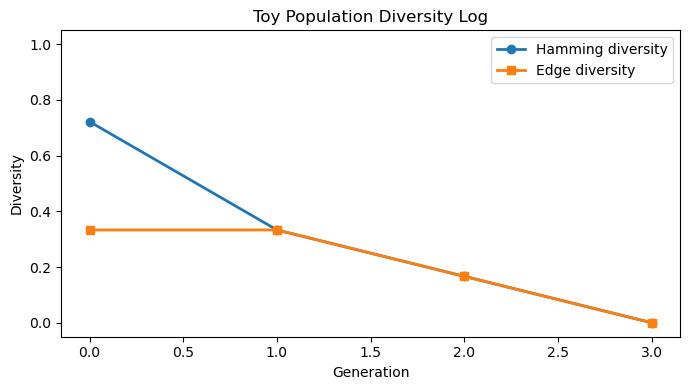

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(diversity_log["generation"], diversity_log["diversity"],
        marker="o", linewidth=2, label="Hamming diversity")
ax.plot(diversity_log["generation"], diversity_log["edge_diversity"],
        marker="s", linewidth=2, label="Edge diversity")

ax.set_xlabel("Generation")
ax.set_ylabel("Diversity")
ax.set_title("Toy Population Diversity Log")
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


## Integration Note

`run_ga` in `10_ga_loop.ipynb` can call `diversity_record` or the underlying metric functions at the same point where it records best and mean fitness. The hook is controlled by `GAConfig.instrument_diversity`, so normal fitness logging remains available when diversity instrumentation is turned off. When enabled, the resulting per-generation log is ready for downstream plotting with columns:

`generation`, `best_fitness`, `mean_fitness`, `diversity`, `edge_overlap`, and `edge_diversity`.
